In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [3]:
print("--- Завдання 1 ---")

# 1. Створіть вектор, скаляр, матрицю та тензор [cite: 4]
scalar = tf.constant(7)
vector = tf.constant([10, 10])
matrix = tf.constant([[1, 2], [3, 4]])
tensor = tf.constant([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]])

print(f"Scalar: {scalar}\nVector: {vector}\nMatrix: {matrix}\nTensor: {tensor}\n")

# 2. Знайдіть форму, ранг та розмір тензорів [cite: 5]
for name, t in zip(["Scalar", "Vector", "Matrix", "Tensor"], [scalar, vector, matrix, tensor]):
    print(f"{name} -> Shape: {t.shape}, Rank (ndim): {t.ndim}, Size: {tf.size(t)}")

# 3. Створіть два тензори з випадковими значеннями (0..1) форми [5, 300] [cite: 6]
tf.random.set_seed(42) # Для відтворюваності
tensor_A = tf.random.uniform(shape=[5, 300], minval=0, maxval=1)
tensor_B = tf.random.uniform(shape=[5, 300], minval=0, maxval=1)
print(f"\nTensor A shape: {tensor_A.shape}, Tensor B shape: {tensor_B.shape}")

# 4. Помножте два тензори за допомогою множення матриць [cite: 7]
# Примітка: [5, 300] не можна помножити на [5, 300]. Потрібно транспонувати один з них.
# Виконаємо A * B.T, щоб отримати [5, 5]
matrix_mult_result = tf.matmul(tensor_A, tf.transpose(tensor_B))
print(f"\nMatrix Multiplication Result Shape (A * B^T): {matrix_mult_result.shape}")

# 5. Помножте два тензори за допомогою скалярного добутку [cite: 8]
# Варіант А: Якщо мається на увазі поелементне множення (Hadamard product)
element_wise = tf.multiply(tensor_A, tensor_B)
# Варіант Б: Якщо мається на увазі Tensordot (сума добутків)
dot_product = tf.tensordot(tensor_A, tensor_B, axes=[[0, 1], [0, 1]]) # Повне згортання в скаляр
print(f"Dot product result (scalar): {dot_product}")

# 6. Створіть тензор [224, 224, 3] [cite: 9]
random_image = tf.random.uniform(shape=[224, 224, 3], minval=0, maxval=1)
print(f"\nRandom Image Tensor Shape: {random_image.shape}")

# 7. Знайдіть мінімальне та максимальне значення [cite: 10]
min_val = tf.reduce_min(random_image)
max_val = tf.reduce_max(random_image)
print(f"Min value: {min_val}, Max value: {max_val}")

# 8. Створіть тензор [1, 224, 224, 3] та стисніть до [224, 224, 3] [cite: 11, 12]
unsqueezed_tensor = tf.random.uniform(shape=[1, 224, 224, 3])
squeezed_tensor = tf.squeeze(unsqueezed_tensor)
print(f"Original shape: {unsqueezed_tensor.shape}, Squeezed shape: {squeezed_tensor.shape}")

# 9. Тензор форми [10], знайти індекс максимального значення [cite: 13, 14]
tensor_10 = tf.constant([1, 5, 2, 9, 3, 8, 15, 0, 4, 6])
max_index = tf.argmax(tensor_10)
print(f"\nTensor [10]: {tensor_10.numpy()}")
print(f"Index of max value: {max_index}")

# 10. One-hot кодування [cite: 15]
# One-hot кодування зазвичай застосовується до індексів, тому закодуємо знайдений індекс
# або перетворимо весь тензор, якщо розглядати його як набір класів (глибина повинна бути > макс значення)
one_hot_encoded = tf.one_hot(tensor_10, depth=16) # depth=16 бо макс значення 15
print(f"One-hot encoded shape: {one_hot_encoded.shape}")

--- Завдання 1 ---
Scalar: 7
Vector: [10 10]
Matrix: [[1 2]
 [3 4]]
Tensor: [[[ 1  2  3]
  [ 4  5  6]]

 [[ 7  8  9]
  [10 11 12]]]

Scalar -> Shape: (), Rank (ndim): 0, Size: 1
Vector -> Shape: (2,), Rank (ndim): 1, Size: 2
Matrix -> Shape: (2, 2), Rank (ndim): 2, Size: 4
Tensor -> Shape: (2, 2, 3), Rank (ndim): 3, Size: 12

Tensor A shape: (5, 300), Tensor B shape: (5, 300)

Matrix Multiplication Result Shape (A * B^T): (5, 5)
Dot product result (scalar): 382.34564208984375

Random Image Tensor Shape: (224, 224, 3)
Min value: 2.384185791015625e-07, Max value: 0.999991774559021
Original shape: (1, 224, 224, 3), Squeezed shape: (224, 224, 3)

Tensor [10]: [ 1  5  2  9  3  8 15  0  4  6]
Index of max value: 6
One-hot encoded shape: (10, 16)


In [4]:
print("\n--- Завдання 2 ---")
# Перевірка наявності GPU
physical_devices = tf.config.list_physical_devices('GPU')
print("GPUs Available: ", len(physical_devices))
if len(physical_devices) > 0:
    print("Device details:", physical_devices)
else:
    print("Running on CPU")


--- Завдання 2 ---
GPUs Available:  0
Running on CPU


In [5]:
print("\n--- Завдання 3 ---")

# --- Дані для Регресії ---
# Генеруємо X від 0 до 50
X_reg = tf.range(0, 50, delta=0.5, dtype=tf.float32)
# y = 2x + 5 + шум
noise = tf.random.normal(shape=X_reg.shape, mean=0.0, stddev=4.0)
y_reg = 2 * X_reg + 5 + noise

print(f"Regression Data: X shape {X_reg.shape}, y shape {y_reg.shape}")

# --- Дані для Класифікації ---
# Створимо два кластери точок
n_samples = 100
# Клас 0 (центр в 2, 2)
class_0_x = tf.random.normal(shape=(n_samples,), mean=2, stddev=1)
class_0_y = tf.random.normal(shape=(n_samples,), mean=2, stddev=1)
class_0_labels = tf.zeros(shape=(n_samples,))

# Клас 1 (центр в 6, 6)
class_1_x = tf.random.normal(shape=(n_samples,), mean=6, stddev=1)
class_1_y = tf.random.normal(shape=(n_samples,), mean=6, stddev=1)
class_1_labels = tf.ones(shape=(n_samples,))

# Об'єднуємо
X_class_features = tf.concat([
    tf.stack([class_0_x, class_0_y], axis=1),
    tf.stack([class_1_x, class_1_y], axis=1)
], axis=0)
y_class_labels = tf.concat([class_0_labels, class_1_labels], axis=0)

print(f"Classification Data: X shape {X_class_features.shape}, y shape {y_class_labels.shape}")


--- Завдання 3 ---
Regression Data: X shape (100,), y shape (100,)
Classification Data: X shape (200, 2), y shape (200,)



--- Завдання 4 ---


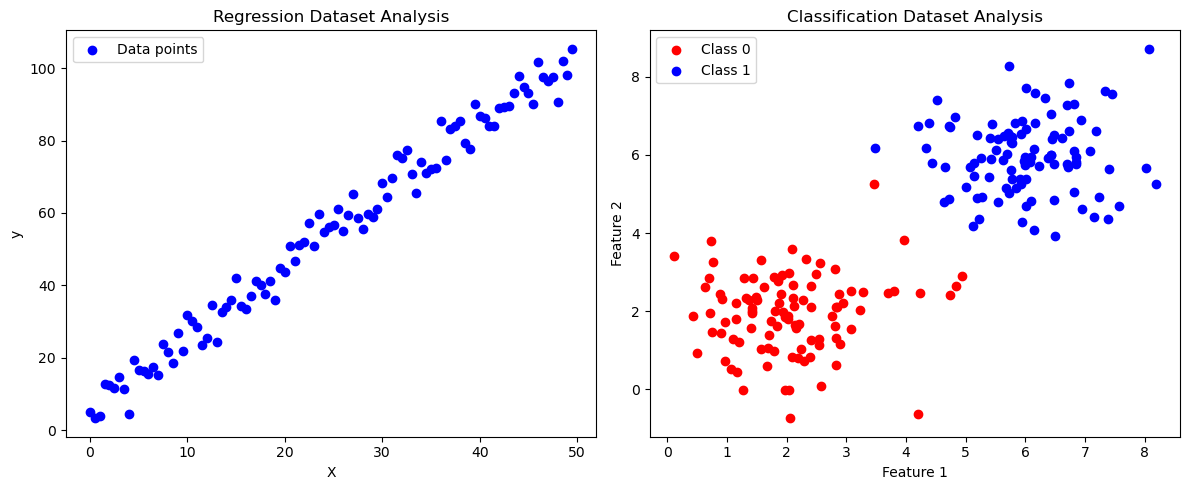

In [6]:
print("\n--- Завдання 4 ---")

plt.figure(figsize=(12, 5))

# Графік Регресії
plt.subplot(1, 2, 1)
plt.scatter(X_reg, y_reg, c='b', label='Data points')
plt.title("Regression Dataset Analysis")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()

# Графік Класифікації
plt.subplot(1, 2, 2)
# Розділяємо для кольорів на графіку
plt.scatter(X_class_features[:n_samples, 0], X_class_features[:n_samples, 1], c='red', label='Class 0')
plt.scatter(X_class_features[n_samples:, 0], X_class_features[n_samples:, 1], c='blue', label='Class 1')
plt.title("Classification Dataset Analysis")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

plt.tight_layout()
plt.show()